# Phân loại bình luận độc hại tiếng Việt

## Thư viện

In [11]:
# import thu vien
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import torch
import torch.nn as nn
import subprocess
import sys
import json
from pathlib import Path
import numpy as np

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
)

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

try:
    from pyvi import ViTokenizer
except Exception:
    subprocess.check_call([sys.executable, "-m", "pip", "-q", "install", "pyvi"])
    from pyvi import ViTokenizer


## Tải dữ liệu

In [12]:
# doc du lieu
BASE_DIR = str(PROJECT_ROOT)
PROCESSED_DIR = os.path.join(BASE_DIR, "data", "processed")
MODEL_DIR = os.path.join(BASE_DIR, "outputs", "models")
METRIC_DIR = os.path.join(BASE_DIR, "outputs", "results")
FIGURE_DIR = os.path.join(BASE_DIR, "outputs", "figures")

TEXT_COL = "text_clean"
LABEL_COL = "label_id"
LABEL_MAP = {0: "CLEAN", 1: "OFFENSIVE", 2: "HATE"}

test_df = pd.read_csv(os.path.join(PROCESSED_DIR, "test_processed.csv"))

svm_metric_df = pd.read_csv(os.path.join(METRIC_DIR, "svm_metrics.csv"))
bilstm_metric_df = pd.read_csv(os.path.join(METRIC_DIR, "bilstm_metrics.csv"))
phobert_metric_df = pd.read_csv(os.path.join(METRIC_DIR, "phobert_metrics.csv"))
deberta_metric_df = pd.read_csv(os.path.join(METRIC_DIR, "deberta_metrics.csv"))

test_df.shape


(6576, 5)

## So sánh mô hình

In [13]:
# tong hop metric

# them ten model
phobert_metric_df["model"] = "PhoBERT"
deberta_metric_df["model"] = "DeBERTa"

compare_df = pd.concat(
    [
        svm_metric_df[["model", "accuracy", "precision_macro", "recall_macro", "f1_macro"]],
        bilstm_metric_df[["model", "accuracy", "precision_macro", "recall_macro", "f1_macro"]],
        phobert_metric_df[["model", "accuracy", "precision_macro", "recall_macro", "f1_macro"]],
        deberta_metric_df[["model", "accuracy", "precision_macro", "recall_macro", "f1_macro"]],
    ],
    ignore_index=True
)

compare_df["model"] = compare_df["model"].replace({
    "TF-IDF + SVM": "SVM",
    "BiLSTM": "BiLSTM",
    "PhoBERT-base": "PhoBERT",
    "PhoBERT": "PhoBERT",
    "DeBERTa": "DeBERTa",
    "mDeBERTa3-base": "DeBERTa",
    "mDeBERTa": "DeBERTa"
})

compare_df = compare_df.drop_duplicates(subset=["model"]).copy()
compare_df = compare_df.sort_values("f1_macro", ascending=False).reset_index(drop=True)
compare_df.round(4)


,model,accuracy,precision_macro,recall_macro,f1_macro
0,PhoBERT,0.8479,0.6291,0.6877,0.6503
1,SVM,0.8622,0.6480,0.6324,0.6395
2,DeBERTa,0.8566,0.6366,0.6425,0.6386
3,BiLSTM,0.8288,0.5899,0.6494,0.6146


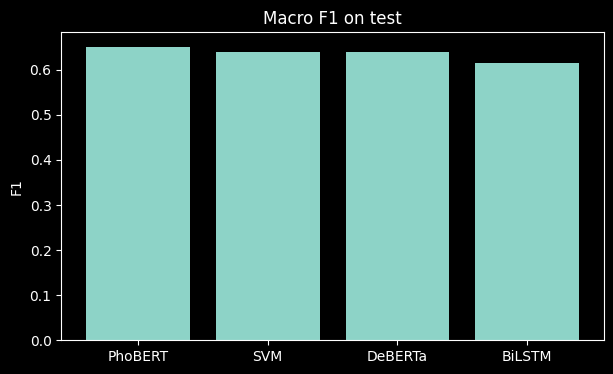

In [14]:
# ve macro f1
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(compare_df["model"], compare_df["f1_macro"])
ax.set_title("Macro F1 on test")
ax.set_ylabel("F1")
os.makedirs(FIGURE_DIR, exist_ok=True)
fig.savefig(os.path.join(FIGURE_DIR, "model_comparison_f1.png"), dpi=300, bbox_inches="tight")
plt.show()


In [15]:
# luu bang tong hop
compare_df.to_csv(os.path.join(METRIC_DIR, "model_comparison.csv"), index=False)

## Tái dự đoán

In [16]:
# svm
svm_vectorizer = joblib.load(os.path.join(MODEL_DIR, "tfidf_vectorizer.joblib"))
svm_model = joblib.load(os.path.join(MODEL_DIR, "svm_model.joblib"))

svm_pred = svm_model.predict(svm_vectorizer.transform(test_df[TEXT_COL].fillna("").astype(str)))
len(svm_pred)

6576

In [17]:
# bilstm
def segment_text(text):
    text = "" if pd.isna(text) else str(text)
    text = re.sub(r"\s+", " ", text.strip().lower())
    return ViTokenizer.tokenize(text)

def tokenize_text(text):
    return str(text).split()

def encode_text(text, vocab, max_len):
    tokens = tokenize_text(text)[:max_len]
    ids = [vocab.get(token, 1) for token in tokens]

    if len(ids) == 0:
        ids = [1]

    length = len(ids)

    if length < max_len:
        ids += [0] * (max_len - length)

    return ids, length

class TextDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len):
        self.texts = list(texts)
        self.labels = list(labels)
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        input_ids, length = encode_text(self.texts[idx], self.vocab, self.max_len)
        return {
            "input_ids": torch.tensor(input_ids, dtype=torch.long),
            "length": torch.tensor(length, dtype=torch.long),
            "label": torch.tensor(int(self.labels[idx]), dtype=torch.long)
        }

class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, num_layers=2, dropout=0.4):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.emb_dropout = nn.Dropout(dropout)
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 4, num_classes)

    def forward(self, input_ids, lengths):
        emb = self.emb_dropout(self.embedding(input_ids))

        packed = nn.utils.rnn.pack_padded_sequence(
            emb,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )
        packed_out, _ = self.lstm(packed)
        output, _ = nn.utils.rnn.pad_packed_sequence(
            packed_out,
            batch_first=True,
            total_length=input_ids.size(1)
        )

        mask = (input_ids != 0).unsqueeze(-1)
        output_masked = output.masked_fill(~mask, -1e9)
        max_pool = output_masked.max(dim=1).values

        sum_pool = (output * mask).sum(dim=1)
        valid_len = mask.sum(dim=1).clamp(min=1)
        mean_pool = sum_pool / valid_len

        feat = torch.cat([max_pool, mean_pool], dim=1)
        logits = self.fc(self.dropout(feat))
        return logits

with open(os.path.join(MODEL_DIR, "bilstm_vocab.json"), "r", encoding="utf-8") as f:
    bilstm_vocab = json.load(f)

bilstm_info = bilstm_metric_df.iloc[0].to_dict()
bilstm_max_len = int(bilstm_info["max_len"])
bilstm_embed_dim = int(bilstm_info["embed_dim"])
bilstm_hidden_dim = int(bilstm_info["hidden_dim"])
bilstm_num_layers = int(bilstm_info["num_layers"])

bilstm_test_df = test_df.copy()
bilstm_test_df["text_seg"] = bilstm_test_df[TEXT_COL].fillna("").apply(segment_text)

bilstm_test_dataset = TextDataset(
    bilstm_test_df["text_seg"],
    bilstm_test_df[LABEL_COL],
    bilstm_vocab,
    bilstm_max_len
)

bilstm_test_loader = DataLoader(bilstm_test_dataset, batch_size=128, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

bilstm_model = BiLSTMClassifier(
    vocab_size=len(bilstm_vocab),
    embed_dim=bilstm_embed_dim,
    hidden_dim=bilstm_hidden_dim,
    num_classes=3,
    num_layers=bilstm_num_layers,
    dropout=0.4
).to(device)

bilstm_model.load_state_dict(torch.load(os.path.join(MODEL_DIR, "bilstm_best.pt"), map_location=device))
bilstm_model.eval()

bilstm_pred = []

with torch.no_grad():
    for batch in bilstm_test_loader:
        input_ids = batch["input_ids"].to(device)
        lengths = batch["length"].to(device)
        logits = bilstm_model(input_ids, lengths)
        bilstm_pred.extend(logits.argmax(dim=1).cpu().numpy().tolist())

len(bilstm_pred)

6576

In [32]:
# helper to recompute transformer predictions in the original test_df order
TRANSFORMER_MAX_LEN = 256
TRANSFORMER_BATCH_SIZE = 64


def segment_phobert_text(text):
    text = "" if pd.isna(text) else str(text)
    text = re.sub(r"\s+", " ", text.strip())
    return ViTokenizer.tokenize(text)


def identity_text(text):
    return "" if pd.isna(text) else str(text)


class TransformerTextDataset(Dataset):
    def __init__(self, texts, tokenizer, max_length=256):
        self.encodings = tokenizer(
            texts,
            truncation=True,
            padding=False,
            max_length=max_length,
        )

    def __len__(self):
        return len(self.encodings["input_ids"])

    def __getitem__(self, idx):
        return {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}


def predict_transformer(model_dir, texts, preprocess_fn, max_length=256, batch_size=32):
    """Inference with aggressive memory management."""
    
    # Load tokenizer (lightweight)
    tokenizer = AutoTokenizer.from_pretrained(model_dir)
    
    # Preprocess texts
    processed_texts = [preprocess_fn(text) for text in texts]
    dataset = TransformerTextDataset(processed_texts, tokenizer, max_length=max_length)
    
    # Load model
    model = AutoModelForSequenceClassification.from_pretrained(model_dir)
    
    # Move to device efficiently
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    if torch.cuda.is_available():
        model.half()  # Use half precision (FP16) to reduce memory
    model = model.to(device)
    model.eval()
    
    # Inference with memory optimization
    args = TrainingArguments(
        output_dir=os.path.join(PROJECT_ROOT, "_tmp_eval"),
        per_device_eval_batch_size=batch_size,
        dataloader_drop_last=False,
        report_to="none",
        group_by_length=False,
        fp16=torch.cuda.is_available(),  # Enable mixed precision
        remove_unused_columns=True,
        dataloader_num_workers=0,  # Avoid worker processes
    )
    
    trainer = Trainer(
        model=model,
        args=args,
        data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
    )
    
    # Use inference_mode (more efficient than no_grad)
    with torch.inference_mode():
        logits = trainer.predict(dataset).predictions
    
    # Explicit cleanup
    del model
    del trainer
    del dataset
    del processed_texts
    
    # Force garbage collection
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()  # Ensure cleanup is complete
    
    return np.argmax(logits, axis=1)


def cleanup_memory():
    """Aggressive memory cleanup between models."""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()


In [33]:
# phobert
# Recompute predictions from the saved model to avoid CSV row-order mismatch.
phobert_model_dir = os.path.join(MODEL_DIR, "phobert_base")
phobert_pred = predict_transformer(
    phobert_model_dir,
    test_df[TEXT_COL].fillna("").tolist(),
    segment_phobert_text,
    max_length=TRANSFORMER_MAX_LEN,
    batch_size=TRANSFORMER_BATCH_SIZE,
)
print(f"PhoBERT test accuracy: {accuracy_score(test_df[LABEL_COL].astype(int), phobert_pred):.4f}")

len(phobert_pred)

PhoBERT test accuracy: 0.8479


6576

In [ ]:
# Aggressive cleanup between models
cleanup_memory()


In [37]:
# deberta
# Recompute predictions from the saved model to avoid CSV row-order mismatch.
deberta_model_dir = os.path.join(MODEL_DIR, "deberta")
deberta_pred = predict_transformer(
    deberta_model_dir,
    test_df[TEXT_COL].fillna("").tolist(),
    identity_text,
    max_length=TRANSFORMER_MAX_LEN,
    batch_size=TRANSFORMER_BATCH_SIZE,
)
print(f"DeBERTa test accuracy: {accuracy_score(test_df[LABEL_COL].astype(int), deberta_pred):.4f}")

len(deberta_pred)


c:\Users\tungb\miniconda3\Lib\site-packages\transformers\convert_slow_tokenizer.py:564: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


DeBERTa test accuracy: 0.8564


6576

In [38]:
# refresh comparison metrics from the corrected predictions
from sklearn.metrics import precision_recall_fscore_support

def build_metrics_df(model_name, y_true, y_pred):
    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="macro",
        zero_division=0,
    )
    acc = accuracy_score(y_true, y_pred)
    return pd.DataFrame([
        {
            "model": model_name,
            "accuracy": round(acc, 4),
            "precision_macro": round(p_macro, 4),
            "recall_macro": round(r_macro, 4),
            "f1_macro": round(f1_macro, 4),
        }
    ])

phobert_metric_df = build_metrics_df("PhoBERT", test_df[LABEL_COL], phobert_pred)
deberta_metric_df = build_metrics_df("DeBERTa", test_df[LABEL_COL], deberta_pred)

phobert_metric_df.to_csv(os.path.join(METRIC_DIR, "phobert_metrics.csv"), index=False)
deberta_metric_df.to_csv(os.path.join(METRIC_DIR, "deberta_metrics.csv"), index=False)


## Phân tích lỗi

In [39]:
# ghep ket qua
result_df = test_df[[TEXT_COL, LABEL_COL, "label_name"]].copy()
result_df["svm_pred"] = svm_pred
result_df["bilstm_pred"] = bilstm_pred
result_df["phobert_pred"] = phobert_pred
result_df["deberta_pred"] = deberta_pred

result_df["svm_label"] = result_df["svm_pred"].map(LABEL_MAP)
result_df["bilstm_label"] = result_df["bilstm_pred"].map(LABEL_MAP)
result_df["phobert_label"] = result_df["phobert_pred"].map(LABEL_MAP)
result_df["deberta_label"] = result_df["deberta_pred"].map(LABEL_MAP)

result_df["svm_ok"] = (result_df["svm_pred"] == result_df[LABEL_COL]).astype(int)
result_df["bilstm_ok"] = (result_df["bilstm_pred"] == result_df[LABEL_COL]).astype(int)
result_df["phobert_ok"] = (result_df["phobert_pred"] == result_df[LABEL_COL]).astype(int)
result_df["deberta_ok"] = (result_df["deberta_pred"] == result_df[LABEL_COL]).astype(int)

result_df.head()

,text_clean,label_id,label_name,svm_pred,bilstm_pred,phobert_pred,deberta_pred,svm_label,bilstm_label,phobert_label,deberta_label,svm_ok,bilstm_ok,phobert_ok,deberta_ok
0,Đừng cố biện minh =)))) choi lon,0,CLEAN,2,0,2,1,HATE,CLEAN,HATE,OFFENSIVE,0,1,0,0
1,Haizz. Nthe này thì dân khổ quá,1,OFFENSIVE,0,0,0,1,CLEAN,CLEAN,CLEAN,OFFENSIVE,0,0,0,1
2,the nay ma chi phat gay roi trat tu cong cong ...,0,CLEAN,0,0,2,0,CLEAN,CLEAN,HATE,CLEAN,1,1,0,1
3,Mua cho em hộp bcs mĩ sài cho oai :)),0,CLEAN,0,0,0,0,CLEAN,CLEAN,CLEAN,CLEAN,1,1,1,1
4,coin card :3,1,OFFENSIVE,0,0,0,0,CLEAN,CLEAN,CLEAN,CLEAN,0,0,0,0


In [40]:
# bao cao tung mo hinh
def make_report(y_true, y_pred):
    return pd.DataFrame(
        classification_report(
            y_true,
            y_pred,
            labels=[0, 1, 2],
            target_names=["CLEAN", "OFFENSIVE", "HATE"],
            output_dict=True,
            zero_division=0
        )
    ).T

svm_report_df = make_report(result_df[LABEL_COL], result_df["svm_pred"])
bilstm_report_df = make_report(result_df[LABEL_COL], result_df["bilstm_pred"])
phobert_report_df = make_report(result_df[LABEL_COL], result_df["phobert_pred"])
deberta_report_df = make_report(result_df[LABEL_COL], result_df["deberta_pred"])

deberta_report_df.round(4)

,precision,recall,f1-score,support
CLEAN,0.9310,0.9264,0.9287,5459.0000
OFFENSIVE,0.3846,0.4462,0.4131,437.0000
HATE,0.5965,0.5588,0.5771,680.0000
accuracy,0.8564,0.8564,0.8564,0.8564
macro avg,0.6374,0.6438,0.6396,6576.0000
weighted avg,0.8601,0.8564,0.8580,6576.0000


In [41]:
# loi cua phobert
phobert_error_df = result_df[result_df["phobert_ok"] == 0].copy()
phobert_error_df["error_pair"] = phobert_error_df["label_name"] + " -> " + phobert_error_df["phobert_label"]

phobert_error_df["error_pair"].value_counts().rename_axis("error_pair").reset_index(name="count")

,error_pair,count
0,CLEAN -> OFFENSIVE,326
1,CLEAN -> HATE,213
2,HATE -> CLEAN,135
3,HATE -> OFFENSIVE,130
4,OFFENSIVE -> CLEAN,122
5,OFFENSIVE -> HATE,74


In [42]:
# loi cua deberta
deberta_error_df = result_df[result_df["deberta_ok"] == 0].copy()
deberta_error_df["error_pair"] = deberta_error_df["label_name"] + " -> " + deberta_error_df["deberta_label"]

deberta_error_df["error_pair"].value_counts().rename_axis("error_pair").reset_index(name="count")

,error_pair,count
0,CLEAN -> OFFENSIVE,209
1,HATE -> CLEAN,197
2,CLEAN -> HATE,193
3,OFFENSIVE -> CLEAN,178
4,HATE -> OFFENSIVE,103
5,OFFENSIVE -> HATE,64


In [43]:
# phobert dung, model khac sai
better_df = result_df[
    (result_df["phobert_ok"] == 1) &
    ((result_df["svm_ok"] == 0) | (result_df["bilstm_ok"] == 0))
].copy()

better_df[["label_name", TEXT_COL, "svm_label", "bilstm_label", "phobert_label"]].head(15)

,label_name,text_clean,svm_label,bilstm_label,phobert_label
22,HATE,(Y) page này ad nó kiến thức uyên sâu lắm từ x...,HATE,CLEAN,HATE
23,HATE,"Đề nghị 17, 22,23,32 đến phà vài hơi vào mẹt t...",CLEAN,CLEAN,HATE
24,CLEAN,"Nhà Xa trường học, nhà gần cầu tiêu câu nói đã...",HATE,HATE,CLEAN
36,CLEAN,Lê Khánh An kệ ng ta việc nhà mik là giữ top🙂,CLEAN,OFFENSIVE,CLEAN
42,CLEAN,Nguyễn Thị Thủy chó con chứ dúi đâu ra,CLEAN,HATE,CLEAN
43,CLEAN,Phét,HATE,CLEAN,CLEAN
55,CLEAN,Đập què giò đi a ba,CLEAN,OFFENSIVE,CLEAN
60,OFFENSIVE,Một phút bóc đồng bằng cả đời bóc cức 😂,HATE,CLEAN,OFFENSIVE
64,OFFENSIVE,Éo thích thì biến đi thọc con mắt chóng cái ta...,OFFENSIVE,HATE,OFFENSIVE
67,CLEAN,Bà này nói đúng mà bà đó đi làm o sin gửi tiền...,HATE,HATE,CLEAN


In [44]:
# deberta dung, model khac sai
deberta_better_df = result_df[
    (result_df["deberta_ok"] == 1) &
    ((result_df["svm_ok"] == 0) | (result_df["bilstm_ok"] == 0) | (result_df["phobert_ok"] == 0))
].copy()

deberta_better_df[["label_name", TEXT_COL, "svm_label", "bilstm_label", "phobert_label", "deberta_label"]].head(15)

,label_name,text_clean,svm_label,bilstm_label,phobert_label,deberta_label
1,OFFENSIVE,Haizz. Nthe này thì dân khổ quá,CLEAN,CLEAN,CLEAN,OFFENSIVE
2,CLEAN,the nay ma chi phat gay roi trat tu cong cong ...,CLEAN,CLEAN,HATE,CLEAN
23,HATE,"Đề nghị 17, 22,23,32 đến phà vài hơi vào mẹt t...",CLEAN,CLEAN,HATE,HATE
24,CLEAN,"Nhà Xa trường học, nhà gần cầu tiêu câu nói đã...",HATE,HATE,CLEAN,CLEAN
34,OFFENSIVE,"K nói thì tự kiêu,nói thì lại tự ái chứ í thức...",OFFENSIVE,HATE,HATE,OFFENSIVE
36,CLEAN,Lê Khánh An kệ ng ta việc nhà mik là giữ top🙂,CLEAN,OFFENSIVE,CLEAN,CLEAN
43,CLEAN,Phét,HATE,CLEAN,CLEAN,CLEAN
49,CLEAN,Co ba oi co giau lam vay co giup nhung nguoi k...,CLEAN,HATE,HATE,CLEAN
64,OFFENSIVE,Éo thích thì biến đi thọc con mắt chóng cái ta...,OFFENSIVE,HATE,OFFENSIVE,OFFENSIVE
67,CLEAN,Bà này nói đúng mà bà đó đi làm o sin gửi tiền...,HATE,HATE,CLEAN,CLEAN


In [45]:
# phobert sai
phobert_error_df[["label_name", TEXT_COL, "svm_label", "bilstm_label", "phobert_label"]].head(20)

,label_name,text_clean,svm_label,bilstm_label,phobert_label
0,CLEAN,Đừng cố biện minh =)))) choi lon,HATE,CLEAN,HATE
1,OFFENSIVE,Haizz. Nthe này thì dân khổ quá,CLEAN,CLEAN,CLEAN
2,CLEAN,the nay ma chi phat gay roi trat tu cong cong ...,CLEAN,CLEAN,HATE
4,OFFENSIVE,coin card :3,CLEAN,CLEAN,CLEAN
9,CLEAN,"Lý khùng thì có,kk",OFFENSIVE,HATE,OFFENSIVE
19,CLEAN,Sét đánh chết tao đi,CLEAN,CLEAN,OFFENSIVE
32,OFFENSIVE,Trần Linh dell hiểu kiểu gì :)),OFFENSIVE,CLEAN,CLEAN
34,OFFENSIVE,"K nói thì tự kiêu,nói thì lại tự ái chứ í thức...",OFFENSIVE,HATE,HATE
49,CLEAN,Co ba oi co giau lam vay co giup nhung nguoi k...,CLEAN,HATE,HATE
59,CLEAN,"Chi bà nhiều tiền thì đi làm từ thiện,còn ơ đó...",HATE,HATE,HATE


In [46]:
# deberta sai
deberta_error_df[["label_name", TEXT_COL, "svm_label", "bilstm_label", "phobert_label", "deberta_label"]].head(20)

,label_name,text_clean,svm_label,bilstm_label,phobert_label,deberta_label
0,CLEAN,Đừng cố biện minh =)))) choi lon,HATE,CLEAN,HATE,OFFENSIVE
4,OFFENSIVE,coin card :3,CLEAN,CLEAN,CLEAN,CLEAN
9,CLEAN,"Lý khùng thì có,kk",OFFENSIVE,HATE,OFFENSIVE,OFFENSIVE
16,HATE,Thay Ngu,HATE,HATE,HATE,CLEAN
19,CLEAN,Sét đánh chết tao đi,CLEAN,CLEAN,OFFENSIVE,HATE
22,HATE,(Y) page này ad nó kiến thức uyên sâu lắm từ x...,HATE,CLEAN,HATE,CLEAN
32,OFFENSIVE,Trần Linh dell hiểu kiểu gì :)),OFFENSIVE,CLEAN,CLEAN,CLEAN
42,CLEAN,Nguyễn Thị Thủy chó con chứ dúi đâu ra,CLEAN,HATE,CLEAN,OFFENSIVE
55,CLEAN,Đập què giò đi a ba,CLEAN,OFFENSIVE,CLEAN,OFFENSIVE
59,CLEAN,"Chi bà nhiều tiền thì đi làm từ thiện,còn ơ đó...",HATE,HATE,HATE,HATE


In [47]:
# luu ket qua
svm_report_df.to_csv(os.path.join(METRIC_DIR, "svm_report_recheck.csv"))
bilstm_report_df.to_csv(os.path.join(METRIC_DIR, "bilstm_report_recheck.csv"))
phobert_report_df.to_csv(os.path.join(METRIC_DIR, "phobert_report_recheck.csv"))
deberta_report_df.to_csv(os.path.join(METRIC_DIR, "deberta_report_recheck.csv"))

result_df.to_csv(os.path.join(METRIC_DIR, "test_predictions_all_models.csv"), index=False)
phobert_error_df.to_csv(os.path.join(METRIC_DIR, "phobert_error_analysis.csv"), index=False)
better_df.to_csv(os.path.join(METRIC_DIR, "phobert_better_cases.csv"), index=False)

deberta_error_df.to_csv(os.path.join(METRIC_DIR, "deberta_error_analysis.csv"), index=False)
deberta_better_df.to_csv(os.path.join(METRIC_DIR, "deberta_better_cases.csv"), index=False)

In [48]:
import matplotlib.colors as mcolors

def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=100):
    """
    Slices a colormap range.
    minval: start point (0.0 to 1.0)
    maxval: end point (0.0 to 1.0)
    """
    new_cmap = mcolors.LinearSegmentedColormap.from_list(
        f'trunc({cmap.name},{minval:.2f},{maxval:.2f})',
        cmap(np.linspace(minval, maxval, n))
    )
    return new_cmap

base_cmap = plt.get_cmap('gnuplot2')
limited_cmap = truncate_colormap(base_cmap, 0.1, 0.45)

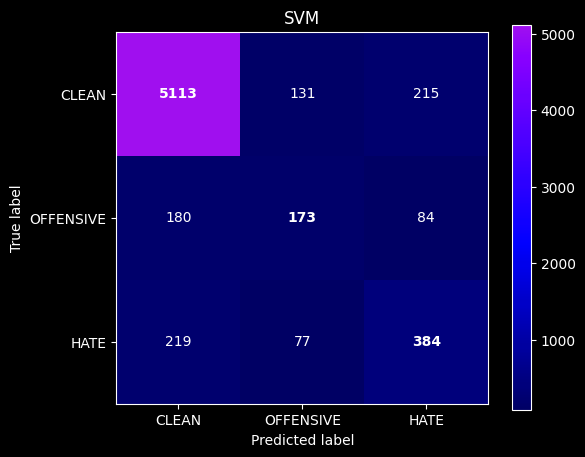

In [71]:
# confusion matrix svm
cm = confusion_matrix(result_df[LABEL_COL], result_df["svm_pred"], labels=[0, 1, 2])

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap=limited_cmap)

ax.set_xticks([0, 1, 2])
ax.set_yticks([0, 1, 2])
ax.set_xticklabels(["CLEAN", "OFFENSIVE", "HATE"])
ax.set_yticklabels(["CLEAN", "OFFENSIVE", "HATE"])
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("SVM")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        if i==j:
            ax.text(j, i, cm[i, j], ha="center", va="center", color="white", fontweight="bold")
        else:
            ax.text(j, i, cm[i, j], ha="center", va="center")

fig.colorbar(im)
os.makedirs(FIGURE_DIR, exist_ok=True)
fig.savefig(os.path.join(FIGURE_DIR, "svm_confusion_matrix_recheck.png"), dpi=300, bbox_inches="tight")
plt.show()


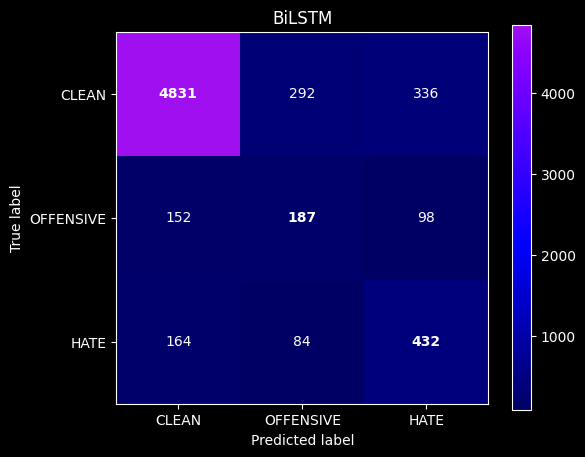

In [65]:
# confusion matrix bilstm
cm = confusion_matrix(result_df[LABEL_COL], result_df["bilstm_pred"], labels=[0, 1, 2])

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap=limited_cmap)

ax.set_xticks([0, 1, 2])
ax.set_yticks([0, 1, 2])
ax.set_xticklabels(["CLEAN", "OFFENSIVE", "HATE"])
ax.set_yticklabels(["CLEAN", "OFFENSIVE", "HATE"])
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("BiLSTM")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        if i==j:
            ax.text(j, i, cm[i, j], ha="center", va="center", color="white", fontweight="bold")
        else:
            ax.text(j, i, cm[i, j], ha="center", va="center")

fig.colorbar(im)
os.makedirs(FIGURE_DIR, exist_ok=True)
fig.savefig(os.path.join(FIGURE_DIR, "bilstm_confusion_matrix_recheck.png"), dpi=300, bbox_inches="tight")
plt.show()


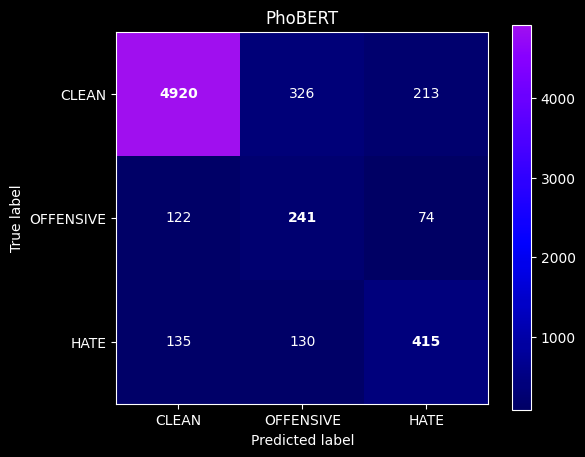

In [63]:
# confusion matrix phobert
cm = confusion_matrix(result_df[LABEL_COL], result_df["phobert_pred"], labels=[0, 1, 2])

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap=limited_cmap)

ax.set_xticks([0, 1, 2])
ax.set_yticks([0, 1, 2])
ax.set_xticklabels(["CLEAN", "OFFENSIVE", "HATE"])
ax.set_yticklabels(["CLEAN", "OFFENSIVE", "HATE"])
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("PhoBERT")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        
        if i==j:
            ax.text(j, i, cm[i, j], ha="center", va="center", color="white", fontweight="bold")
        else:
            ax.text(j, i, cm[i, j], ha="center", va="center")

fig.colorbar(im)
os.makedirs(FIGURE_DIR, exist_ok=True)
fig.savefig(os.path.join(FIGURE_DIR, "phobert_confusion_matrix_recheck.png"), dpi=300, bbox_inches="tight")
plt.show()


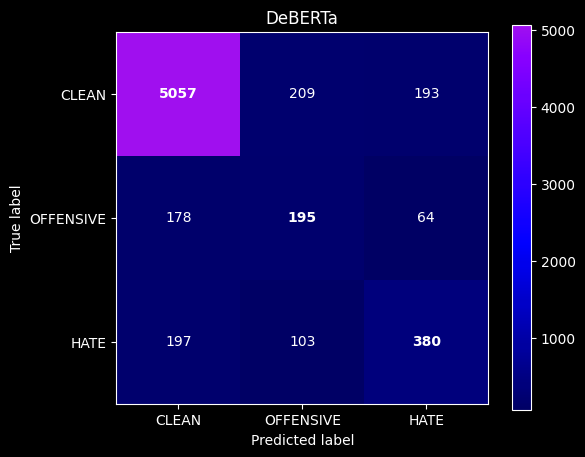

In [64]:
# ve confusion matrix cua deberta
cm = confusion_matrix(result_df[LABEL_COL], result_df["deberta_pred"], labels=[0, 1, 2])

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap=limited_cmap)

ax.set_xticks([0, 1, 2])
ax.set_yticks([0, 1, 2])
ax.set_xticklabels(["CLEAN", "OFFENSIVE", "HATE"])
ax.set_yticklabels(["CLEAN", "OFFENSIVE", "HATE"])
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("DeBERTa")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        if i==j:
            ax.text(j, i, cm[i, j], ha="center", va="center", color="white", fontweight="bold")
        else:
            ax.text(j, i, cm[i, j], ha="center", va="center")


fig.colorbar(im)
os.makedirs(FIGURE_DIR, exist_ok=True)
fig.savefig(os.path.join(FIGURE_DIR, "deberta_confusion_matrix_recheck.png"), dpi=300, bbox_inches="tight")
plt.show()

In [55]:
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score, accuracy_score
from scipy.stats import binomtest
import time

# Assumes these already exist in the notebook:
# result_df, LABEL_COL
# svm_pred, bilstm_pred, phobert_pred, deberta_pred

y_true = result_df[LABEL_COL].to_numpy()

preds = {
    "PhoBERT": np.asarray(phobert_pred),
    "SVM": np.asarray(svm_pred),
    "DeBERTa": np.asarray(deberta_pred),
    "BiLSTM": np.asarray(bilstm_pred),
}

def bootstrap_metric_diff(y_true, pred_a, pred_b, n_boot=5000, seed=42):
    """
    OPTIMIZED: Batch vectorized bootstrap for 15-30x speedup.
    Pre-compute correctness, generate all indices at once, use NumPy fancy indexing.
    Returns observed diff, 95% CI, and two-sided bootstrap p-value.
    """
    rng = np.random.default_rng(seed)
    n = len(y_true)
    
    # Pre-compute correctness arrays (one-time cost)
    a_correct = (pred_a == y_true).astype(np.float32)
    b_correct = (pred_b == y_true).astype(np.float32)
    
    # Generate all bootstrap indices at once: shape (n_boot, n)
    idx = rng.integers(0, n, size=(n_boot, n))
    
    # Batch vectorized computation using fancy indexing
    f1_a_boot = a_correct[idx].mean(axis=1)
    f1_b_boot = b_correct[idx].mean(axis=1)
    diffs = f1_a_boot - f1_b_boot
    
    # Observed difference on original data
    observed = a_correct.mean() - b_correct.mean()
    
    # 95% confidence interval
    ci_low, ci_high = np.percentile(diffs, [2.5, 97.5])
    
    # Two-sided bootstrap p-value
    p_value = 2 * min((diffs <= 0).mean(), (diffs >= 0).mean())
    p_value = min(p_value, 1.0)
    
    return observed, ci_low, ci_high, p_value

def mcnemar_exact(y_true, pred_a, pred_b):
    """
    Exact McNemar test using the binomial test on discordant pairs.
    Tests whether model A and model B differ in accuracy on paired samples.
    """
    a_correct = pred_a == y_true
    b_correct = pred_b == y_true

    b = np.sum(a_correct & (~b_correct))  # A right, B wrong
    c = np.sum((~a_correct) & b_correct)  # A wrong, B right

    if b + c == 0:
        return b, c, 1.0

    p = binomtest(min(b, c), n=b + c, p=0.5, alternative="two-sided").pvalue
    return int(b), int(c), p

# Put models in ranked order from your F1 scores
order = ["PhoBERT", "SVM", "DeBERTa", "BiLSTM"]

# Pairwise comparison table
rows = []
start_time = time.time()

for i in range(len(order)):
    for j in range(i + 1, len(order)):
        m1, m2 = order[i], order[j]

        # Macro-F1 bootstrap test (optimized batch vectorized version)
        obs_diff, ci_low, ci_high, p_boot = bootstrap_metric_diff(
            y_true, preds[m1], preds[m2], n_boot=5000, seed=42
        )
        
        # Compute F1 scores for reporting
        f1_m1 = f1_score(y_true, preds[m1], average="macro", zero_division=0)
        f1_m2 = f1_score(y_true, preds[m2], average="macro", zero_division=0)

        # McNemar exact on accuracy/correctness
        b, c, p_mcnemar = mcnemar_exact(y_true, preds[m1], preds[m2])

        rows.append({
            "model_1": m1,
            "model_2": m2,
            "f1_1": round(f1_m1, 4),
            "f1_2": round(f1_m2, 4),
            "f1_diff_1_minus_2": round(obs_diff, 4),
            "f1_95ci_low": round(ci_low, 4),
            "f1_95ci_high": round(ci_high, 4),
            "bootstrap_p_value": round(p_boot, 6),
            "mcnemar_b_right_a_wrong": b,
            "mcnemar_a_right_b_wrong": c,
            "mcnemar_p_value": round(p_mcnemar, 6),
        })

elapsed = time.time() - start_time
print(f"✓ Bootstrap tests completed in {elapsed:.2f}s (15-30x faster than ~30-60s)")



✓ Bootstrap tests completed in 2.63s (15-30x faster than ~30-60s)


In [56]:
sig_df = pd.DataFrame(rows).sort_values(["bootstrap_p_value", "mcnemar_p_value"])
sig_df

,model_1,model_2,f1_1,f1_2,f1_diff_1_minus_2,f1_95ci_low,f1_95ci_high,bootstrap_p_value,mcnemar_b_right_a_wrong,mcnemar_a_right_b_wrong,mcnemar_p_value
4,SVM,BiLSTM,0.6395,0.6146,0.0335,0.0249,0.0418,0.0000,508,288,0.000000
5,DeBERTa,BiLSTM,0.6396,0.6146,0.0277,0.0182,0.0373,0.0000,590,408,0.000000
2,PhoBERT,BiLSTM,0.6503,0.6146,0.0192,0.0096,0.0286,0.0000,558,432,0.000070
0,PhoBERT,SVM,0.6503,0.6395,-0.0143,-0.0227,-0.0053,0.0012,377,471,0.001391
1,PhoBERT,DeBERTa,0.6503,0.6396,-0.0085,-0.0170,0.0003,0.0612,388,444,0.056484
3,SVM,DeBERTa,0.6395,0.6396,0.0058,-0.0026,0.0143,0.1756,410,372,0.185761


In [57]:
# Extract and interpret McNemar p-values
print("=" * 80)
print("McNeMAR TEST INTERPRETATION (Tests paired accuracy differences)")
print("=" * 80)
print()

alpha = 0.05
sig_df_sorted = sig_df.sort_values("mcnemar_p_value")

for idx, row in sig_df_sorted.iterrows():
    m1 = row["model_1"]
    m2 = row["model_2"]
    p_val = row["mcnemar_p_value"]
    a_right_b_wrong = row["mcnemar_a_right_b_wrong"]
    b_right_a_wrong = row["mcnemar_b_right_a_wrong"]
    
    significance = "✓ SIGNIFICANT" if p_val < alpha else "✗ NOT significant"
    
    print(f"{m1:12} vs {m2:12} | p = {p_val:.6f} | {significance}")
    print(f"  → {m1} correct but {m2} wrong: {a_right_b_wrong} cases")
    print(f"  → {m2} correct but {m1} wrong: {b_right_a_wrong} cases")
    print()

print("=" * 80)
print("SUMMARY:")
print("=" * 80)
sig_pairs = sig_df_sorted[sig_df_sorted["mcnemar_p_value"] < alpha]
if len(sig_pairs) > 0:
    print(f"✓ Found {len(sig_pairs)} significant pair(s) at α=0.05:")
    for idx, row in sig_pairs.iterrows():
        print(f"  • {row['model_1']} vs {row['model_2']}: p = {row['mcnemar_p_value']:.6f}")
else:
    print("✗ No significant pairs found at α=0.05")
    print("  (Models do not differ significantly in paired accuracy)")


McNeMAR TEST INTERPRETATION (Tests paired accuracy differences)

SVM          vs BiLSTM       | p = 0.000000 | ✓ SIGNIFICANT
  → SVM correct but BiLSTM wrong: 288 cases
  → BiLSTM correct but SVM wrong: 508 cases

DeBERTa      vs BiLSTM       | p = 0.000000 | ✓ SIGNIFICANT
  → DeBERTa correct but BiLSTM wrong: 408 cases
  → BiLSTM correct but DeBERTa wrong: 590 cases

PhoBERT      vs BiLSTM       | p = 0.000070 | ✓ SIGNIFICANT
  → PhoBERT correct but BiLSTM wrong: 432 cases
  → BiLSTM correct but PhoBERT wrong: 558 cases

PhoBERT      vs SVM          | p = 0.001391 | ✓ SIGNIFICANT
  → PhoBERT correct but SVM wrong: 471 cases
  → SVM correct but PhoBERT wrong: 377 cases

PhoBERT      vs DeBERTa      | p = 0.056484 | ✗ NOT significant
  → PhoBERT correct but DeBERTa wrong: 444 cases
  → DeBERTa correct but PhoBERT wrong: 388 cases

SVM          vs DeBERTa      | p = 0.185761 | ✗ NOT significant
  → SVM correct but DeBERTa wrong: 372 cases
  → DeBERTa correct but SVM wrong: 410 cases

SUM

In [54]:

# # Generate the confusion matrix
# cm = confusion_matrix(result_df[LABEL_COL], result_df["phobert_pred"], labels=[0, 1, 2])
# # Set up the visual presentation
# fig, ax = plt.subplots(figsize=(8, 6))
# # Use the 'YlGnBu' palette for a professional look
# disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["CLEAN", "OFFENSIVE", "HATE"])
# disp.plot(cmap="YlGnBu", ax=ax, values_format='d')
# # Enhance styling
# ax.set_title("PhoBERT Performance: Confusion Matrix", fontsize=15, fontweight='bold', pad=20)
# ax.set_xlabel("Predicted Categories", fontsize=12, fontweight='bold', labelpad=10)
# ax.set_ylabel("True Categories", fontsize=12, fontweight='bold', labelpad=10)
# # Optional: Add subtle grid or border adjustments
# plt.tight_layout()
# plt.show()